# Contraste entre Determinantes Algorítmicos y Teoría Democrática
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** OE5 — contrastar los patrones explicativos con las teorías de
legitimidad, apoyo político, confianza institucional y desempeño democrático
(Easton 1975, Norris 2011, Devine 2024, Lewis-Beck & Stegmaier 2000).

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y definición del marco teórico |
| 3 | Contraste cuantitativo: SHAP vs. predicciones teóricas |
| 4 | Análisis de convergencias y divergencias |
| 5 | Narrativa interpretativa por hipótesis |
| 6 | Tabla y figura de convergencias para la tesis |
| 7 | Discusión de divergencias y nuevas hipótesis |
| 8 | Exportación de material para el paper |

## 1. Importaciones

In [1]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, THEME, PATHS, SPLIT, PAISES_EXCLUIR_EVAL,
    ETIQUETAS, ETIQUETAS_FEATURES, BLOQUES, bloque_de,
)
from utils.io import (
    cargar_shap_values, shap_disponible, cargar_resultados,
    cargar_mejor_modelo,
)
from utils.plots import (
    plot_convergencias_teoricas, plot_tabla_convergencias, save_figure,
)

setup_plots()
print("✓ Importaciones completadas.")

✓ Importaciones completadas.


## 2. Marco teórico de referencia

Se codifican las predicciones de cada teoría como **rangos esperados** de
importancia para cada bloque temático. La comparación es cuantitativa:
¿qué proporción de las top-N variables pertenecen al bloque que la teoría predice?

### Teorías codificadas

| Teoría | Predicción principal |
|---|---|
| **Easton (1975)** — Apoyo político difuso | Confianza institucional como determinante dominante; evaluación económica secundaria |
| **Norris (2011)** — Déficit democrático | Percepción política (brecha expectativas-realidad); context democrático V-Dem alto |
| **Lewis-Beck & Stegmaier (2000)** — Voto económico | Evaluación económica como predictor dominante |
| **Devine (2024)** — Insatisfacción expresiva | Confianza institucional + percepción política > evaluación económica |

In [2]:
# =============================================================================
# Predicciones teóricas: orden esperado de importancia por bloque
# Escala 1 (más importante) → 5 (menos importante)
# =============================================================================

PREDICCIONES_TEORICAS = {
    "Easton (1975)": {
        "Confianza institucional"          : 1,   # central
        "Evaluación económica"             : 2,   # importante
        "Percepción política"              : 3,
        "Corrupción y seguridad"           : 4,
        "Características sociodemográficas": 5,
    },
    "Norris (2011)": {
        "Percepción política"              : 1,   # brecha expectativas-realidad
        "Confianza institucional"          : 2,
        "Corrupción y seguridad"           : 3,
        "Evaluación económica"             : 4,
        "Características sociodemográficas": 5,
    },
    "Lewis-Beck & Stegmaier (2000)": {
        "Evaluación económica"             : 1,   # voto económico
        "Percepción política"              : 2,
        "Confianza institucional"          : 3,
        "Corrupción y seguridad"           : 4,
        "Características sociodemográficas": 5,
    },
    "Devine (2024)": {
        "Confianza institucional"          : 1,
        "Percepción política"              : 2,
        "Evaluación económica"             : 3,
        "Corrupción y seguridad"           : 3,   # empate
        "Características sociodemográficas": 5,
    },
}

print("Marco teórico cargado:")
for teoria, pred in PREDICCIONES_TEORICAS.items():
    top_bloque = min(pred, key=pred.get)
    print(f"  {teoria:<35}: bloque dominante → {top_bloque}")

Marco teórico cargado:
  Easton (1975)                      : bloque dominante → Confianza institucional
  Norris (2011)                      : bloque dominante → Percepción política
  Lewis-Beck & Stegmaier (2000)      : bloque dominante → Evaluación económica
  Devine (2024)                      : bloque dominante → Confianza institucional


## 3. Contraste cuantitativo SHAP vs. predicciones teóricas

In [3]:
# =============================================================================
# Para cada teoría, calcular qué % de las top-N variables pertenece
# al bloque predicho como dominante.
# Se usa el conjunto de prueba (2023+2024) como referencia.
# =============================================================================

# Resolver modelo principal
try:
    sel_path = PATHS["FOLDER_RESULTS"] / "modelo_xai_seleccionado.json"
    if sel_path.exists():
        sel_info = json.loads(sel_path.read_text())
        MODELO_REF = sel_info["modelo_xai"]
    else:
        MODELO_REF = cargar_mejor_modelo("kappa_cuadratico", variante="ordinal_4clases")
except Exception:
    MODELO_REF = "XGBoost"

SP_REF = "test"
print(f"Modelo de referencia: {MODELO_REF} \u2014 {SP_REF}")

# Cargar importancias SHAP
if not shap_disponible(MODELO_REF):
    raise FileNotFoundError(
        f"Valores SHAP no encontrados para {MODELO_REF}.\n"
        "Ejecuta el notebook 04 antes de continuar.")

df_shap_ref  = cargar_shap_values(MODELO_REF)
importancias = df_shap_ref.abs().mean().sort_values(ascending=False)
ranking_alg  = importancias.rank(ascending=False, method="min")

# Calcular importancia por bloque
imp_bloque = {}
for bloque, variables in BLOQUES.items():
    if "V-Dem" in bloque:
        continue
    vars_lb = [v for v in variables if v in importancias.index]
    if vars_lb:
        imp_bloque[bloque] = importancias[vars_lb].sum()

imp_bloque_series = pd.Series(imp_bloque).sort_values(ascending=False)
ranking_bloques   = imp_bloque_series.rank(ascending=False, method="min")

print("\nRanking empírico de bloques por importancia SHAP total:")
for bloque, imp in imp_bloque_series.items():
    rank = int(ranking_bloques[bloque])
    print(f"  {rank}. {bloque:<42}: {imp:.4f}")


Modelo de referencia: CatBoost — test

Ranking empírico de bloques por importancia SHAP total:
  1. Percepción política                       : 0.6290
  2. Evaluación económica                      : 0.5613
  3. Confianza institucional                   : 0.4697
  4. Contexto democrático                      : 0.2655
  5. Corrupción y seguridad                    : 0.1110
  6. Características sociodemográficas         : 0.0061


In [4]:
# =============================================================================
# Contraste cuantitativo: top-N y % por bloque
# =============================================================================
TOP_N_CONTRASTE = 10   # variables top para calcular % de convergencia

# Para cada nivel de top-N, calcular el % de variables del bloque predicho
resultados_contraste = []

for top_n in [5, 10, 15, 20]:
    top_vars = importancias.head(top_n).index.tolist()
    conteo_bloques = {}
    for v in top_vars:
        bl = bloque_de(v)
        if "V-Dem" not in bl:  # excluir V-Dem del conteo
            conteo_bloques[bl] = conteo_bloques.get(bl, 0) + 1

    for teoria, pred in PREDICCIONES_TEORICAS.items():
        bloque_dom = min(pred, key=pred.get)
        n_en_bloque = conteo_bloques.get(bloque_dom, 0)
        n_lb_total  = sum(1 for v in top_vars if "V-Dem" not in bloque_de(v))
        pct = n_en_bloque / n_lb_total * 100 if n_lb_total > 0 else 0
        resultados_contraste.append({
            "teoria": teoria, "top_n": top_n,
            "bloque_predicho": bloque_dom,
            "n_en_bloque": n_en_bloque,
            "pct_convergencia": pct,
        })

df_contraste = pd.DataFrame(resultados_contraste)
print(f"Convergencia con el bloque predicho como dominante (top-{TOP_N_CONTRASTE}):")
sub = df_contraste[df_contraste["top_n"] == TOP_N_CONTRASTE]
for _, row in sub.iterrows():
    print(f"  {row['teoria']:<35}: {row['pct_convergencia']:.0f}% ({row['n_en_bloque']}/{TOP_N_CONTRASTE}) "
          f"del bloque '{row['bloque_predicho']}'")

df_contraste.to_csv(
    PATHS["FOLDER_RESULTS_TABLES"] / f"contraste_teorico_{MODELO_REF}.csv",
    index=False)
print("\n✓ Tabla de contraste guardada")

Convergencia con el bloque predicho como dominante (top-10):
  Easton (1975)                      : 20% (2/10) del bloque 'Confianza institucional'
  Norris (2011)                      : 30% (3/10) del bloque 'Percepción política'
  Lewis-Beck & Stegmaier (2000)      : 30% (3/10) del bloque 'Evaluación económica'
  Devine (2024)                      : 20% (2/10) del bloque 'Confianza institucional'

✓ Tabla de contraste guardada


## 4. Análisis de convergencias y divergencias

In [5]:
# =============================================================================
# Construir tabla detallada de convergencias y divergencias por variable
# para las top-20 variables según SHAP
# =============================================================================

TOP_VAR = 20
top_vars_analisis = importancias.head(TOP_VAR).index.tolist()

filas_tabla = []
for var in top_vars_analisis:
    bloque_var = bloque_de(var)
    if "V-Dem" in bloque_var:
        continue
    rank_alg = int(ranking_alg[var])

    # Para cada teoría: ¿predice este bloque como importante?
    convergencia_teorias = {}
    for teoria, pred in PREDICCIONES_TEORICAS.items():
        rank_esperado = pred.get(bloque_var, 5)
        if rank_esperado <= 2:
            convergencia_teorias[teoria] = "✓ Converge"
        elif rank_esperado == 3:
            convergencia_teorias[teoria] = "~ Parcial"
        else:
            convergencia_teorias[teoria] = "✗ Diverge"

    # Convergencia mayoritaria
    n_conv = sum(1 for v in convergencia_teorias.values() if "✓" in v)
    if n_conv >= 3:
        conv_global = "Convergencia"
    elif n_conv >= 2:
        conv_global = "Parcial"
    else:
        conv_global = "Divergencia"

    fila = {
        "ranking": rank_alg,
        "variable": var,
        "etiqueta": ETIQUETAS_FEATURES.get(var, var),
        "bloque": bloque_var,
        "shap_medio": round(float(importancias[var]), 4),
        "convergencia": conv_global,
    }
    fila.update({t.split("(")[0].strip(): v
                 for t, v in convergencia_teorias.items()})
    filas_tabla.append(fila)

df_tabla_conv = pd.DataFrame(filas_tabla).sort_values("ranking")
print(f"Tabla de convergencias (top-{TOP_VAR} variables LB):")
cols_print = ["ranking","etiqueta","bloque","shap_medio","convergencia"]
print(df_tabla_conv[cols_print].to_string(index=False))

df_tabla_conv.to_csv(
    PATHS["FOLDER_RESULTS_TABLES"] / f"tabla_convergencias_{MODELO_REF}.csv",
    index=False)
print("\n✓ Tabla de convergencias guardada")

Tabla de convergencias (top-20 variables LB):
 ranking                              etiqueta                  bloque  shap_medio convergencia
       1                 Apoyo a la democracia     Percepción política      0.2775 Convergencia
       2              Situación económica país    Evaluación económica      0.2334      Parcial
       3                   Aprobación gobierno     Percepción política      0.1824 Convergencia
       4                    Confianza Gobierno Confianza institucional      0.1679 Convergencia
       5            Distribución ingreso justa    Evaluación económica      0.1487      Parcial
       6           País para todos / poderosos     Percepción política      0.1364 Convergencia
       7                Componente igualitario    Contexto democrático      0.1285  Divergencia
       8        Economía país vs. año anterior    Evaluación económica      0.0943      Parcial
       9            Progreso contra corrupción  Corrupción y seguridad      0.0923  Diverg

## 5. Narrativa interpretativa por hipótesis

In [6]:
# =============================================================================
# H3: Confianza institucional, corrupción y evaluación económica como dominantes
# =============================================================================
print("=" * 65)
print("HIPÓTESIS H3")
print("=" * 65)
print("Predicción: Confianza institucional, corrupción y evaluación")
print("económica serán los determinantes SHAP dominantes.")
print()

bloques_h3 = ["Confianza institucional","Corrupción y seguridad","Evaluación económica"]
top15 = importancias.head(15).index.tolist()

for bloque in bloques_h3:
    vars_bl = [v for v in BLOQUES.get(bloque,[]) if v in importancias.index]
    top_bl  = [v for v in vars_bl if v in top15]
    pct_bl  = len(top_bl) / 15 * 100
    print(f"  {bloque}")
    print(f"    Variables en top-15: {len(top_bl)}/{len(vars_bl)} ({pct_bl:.0f}%)")
    for v in top_bl:
        print(f"      {importancias.rank(ascending=False)[v]:.0f}. "
              f"{ETIQUETAS_FEATURES.get(v,v)}: {importancias[v]:.4f}")

n_h3_en_top15 = sum(1 for v in top15
                    if bloque_de(v) in bloques_h3 and "V-Dem" not in bloque_de(v))
print(f"\n  Total variables de los 3 bloques en top-15: {n_h3_en_top15}/15 "
      f"({n_h3_en_top15/15*100:.0f}%)")
if n_h3_en_top15 / 15 >= 0.6:
    print("  → ✓ H3 CONFIRMADA: los tres bloques concentran ≥60% del top-15.")
else:
    print(f"  → ✗ H3 PARCIALMENTE CONFIRMADA: los tres bloques aportan "
          f"{n_h3_en_top15/15*100:.0f}% del top-15.")

HIPÓTESIS H3
Predicción: Confianza institucional, corrupción y evaluación
económica serán los determinantes SHAP dominantes.

  Confianza institucional
    Variables en top-15: 4/7 (27%)
      10. Confianza Congreso: 0.0867
      4. Confianza Gobierno: 0.1679
      14. Confianza Poder Judicial: 0.0571
      11. Confianza Partidos Políticos: 0.0712
  Corrupción y seguridad
    Variables en top-15: 1/3 (7%)
      9. Progreso contra corrupción: 0.0923
  Evaluación económica
    Variables en top-15: 4/5 (27%)
      2. Situación económica país: 0.2334
      8. Economía país vs. año anterior: 0.0943
      13. Expectativa económica país: 0.0599
      5. Distribución ingreso justa: 0.1487

  Total variables de los 3 bloques en top-15: 9/15 (60%)
  → ✓ H3 CONFIRMADA: los tres bloques concentran ≥60% del top-15.


In [7]:
# =============================================================================
# Cargar datos de estabilidad del NB05 para las hipótesis H4 y H5
# Con diseño de split único, la estabilidad se evalúa entre subregiones
# (no entre períodos temporales).
# =============================================================================
try:
    df_corr_sr = pd.read_csv(
        PATHS["FOLDER_RESULTS_TABLES"] / "spearman_subregiones.csv",
        index_col=0)
    hay_estabilidad = True
except FileNotFoundError:
    hay_estabilidad = False
    print("\u26a0 Datos de estabilidad no encontrados. Ejecuta el notebook 05.")

if hay_estabilidad:
    print("=" * 65)
    print("HIPÓTESIS H4")
    print("=" * 65)
    print("Predicción: corrupción y confianza institucional varían más")
    print("entre subregiones que las características sociodemográficas.")
    print()
    print("  \u2192 ver resultados detallados en NB05 (Cell 16)")
    print("  \u2192 gráfico: results/figures/05_shap_por_subregion.png")
    print()

    print("=" * 65)
    print("HIPÓTESIS H5")
    print("=" * 65)
    print("Predicción: correlación Spearman entre subregiones \u2265 0.7")
    print("(determinantes robustos en toda América Latina).")
    print()

    srs = df_corr_sr.index.tolist()
    n_sr = len(srs)
    vals_tri = [float(df_corr_sr.loc[srs[i], srs[j]])
                for i in range(n_sr) for j in range(i)]
    r_min  = min(vals_tri) if vals_tri else float("nan")
    r_mean = sum(vals_tri) / len(vals_tri) if vals_tri else float("nan")

    print(f"  Correlación mínima entre subregiones: {r_min:.4f}")
    print(f"  Correlación media  entre subregiones: {r_mean:.4f}")
    print()

    if r_min >= 0.7:
        print("  \u2713 H5 CONFIRMADA: r_min \u2265 0.7 \u2014 los determinantes son")
        print("    robustos entre subregiones de América Latina.")
    elif r_min >= 0.5:
        print("  ~ H5 PARCIALMENTE CONFIRMADA: 0.5 \u2264 r_min < 0.7 \u2014")
        print("    los determinantes muestran estabilidad moderada.")
    else:
        print("  \u2717 H5 NO CONFIRMADA: r_min < 0.5 \u2014 existe cambio")
        print("    estructural entre subregiones.")

    print()
    print("Matriz de correlaciones Spearman (subregiones):")
    print(df_corr_sr.to_string())


HIPÓTESIS H4
Predicción: corrupción y confianza institucional varían más
entre subregiones que las características sociodemográficas.

  → ver resultados detallados en NB05 (Cell 16)
  → gráfico: results/figures/05_shap_por_subregion.png

HIPÓTESIS H5
Predicción: correlación Spearman entre subregiones ≥ 0.7
(determinantes robustos en toda América Latina).

  Correlación mínima entre subregiones: 0.9605
  Correlación media  entre subregiones: 0.9814

  ✓ H5 CONFIRMADA: r_min ≥ 0.7 — los determinantes son
    robustos entre subregiones de América Latina.

Matriz de correlaciones Spearman (subregiones):
                 Cono Sur  Región Andina  Brasil  Centroamérica  México y Caribe
Cono Sur           1.0000         0.9802  0.9918         0.9857           0.9857
Región Andina      0.9802         1.0000  0.9846         0.9605           0.9649
Brasil             0.9918         0.9846  1.0000         0.9813           0.9879
Centroamérica      0.9857         0.9605  0.9813         1.0000     

## 6. Figura y tabla de convergencias para la tesis

  ✓ Figura guardada: 06_convergencias_teoricas_CatBoost.png


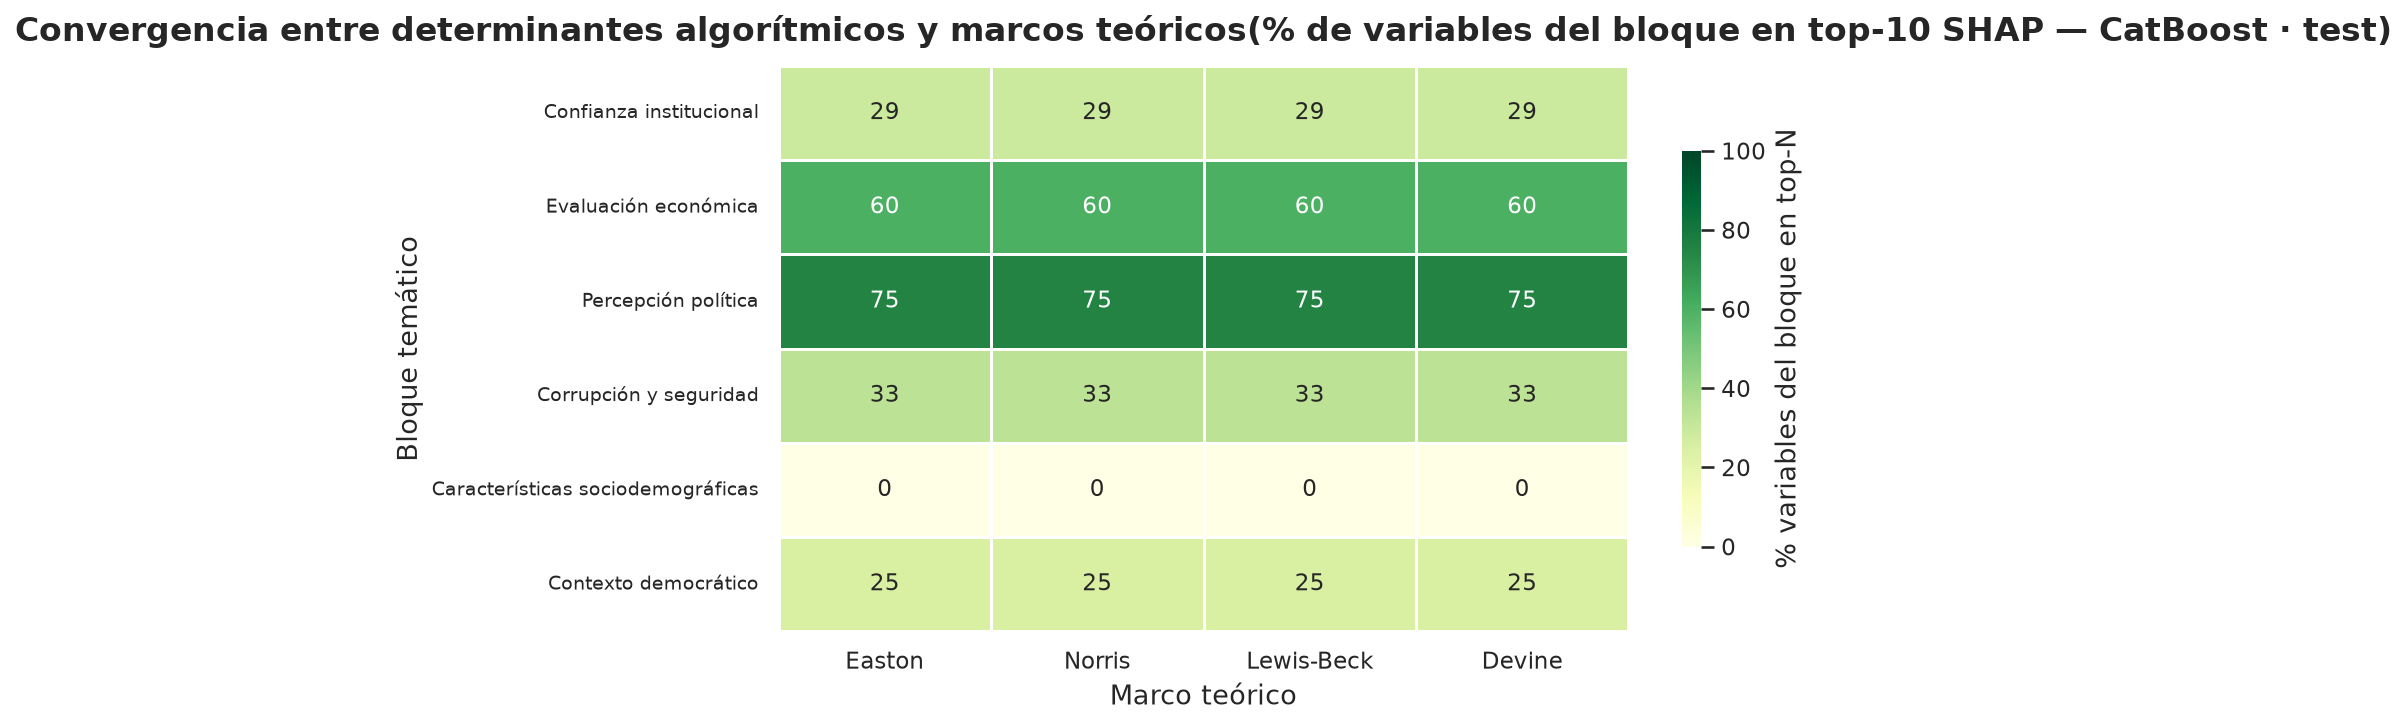

  ✓ Figura guardada: 06_tabla_convergencias_CatBoost.png


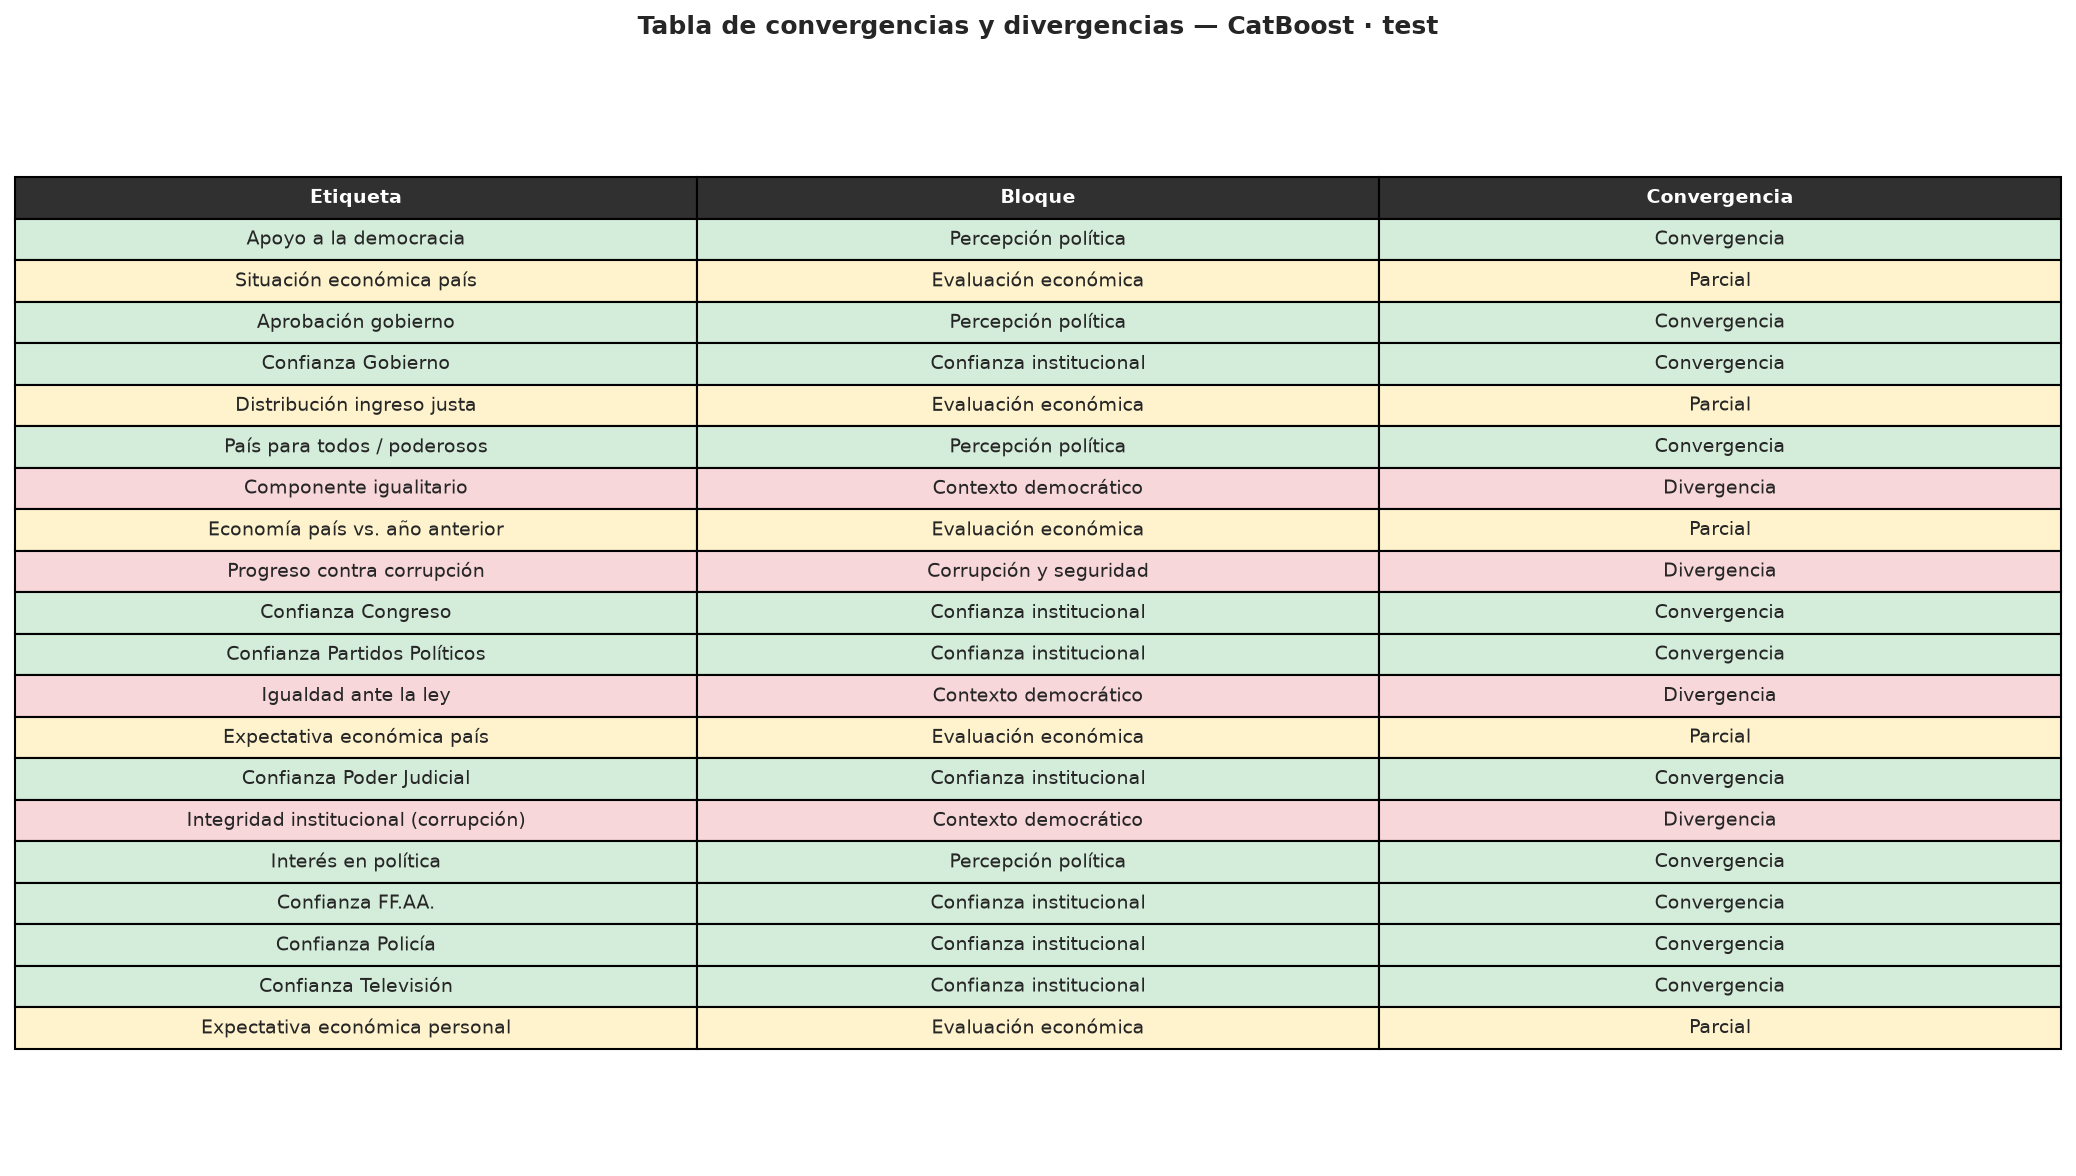

In [8]:
# =============================================================================
# Heatmap de convergencia: bloques × teorías
# =============================================================================
# Construir matriz (bloque × teoría): % de variables del bloque
# que aparecen en el top-10 SHAP
# =============================================================================

bloques_lb = [b for b in BLOQUES if "V-Dem" not in b]
teorias    = list(PREDICCIONES_TEORICAS.keys())
TOP_N_HEAT = 10
top_vars_h = importancias.head(TOP_N_HEAT).index.tolist()

mat_conv = pd.DataFrame(index=bloques_lb, columns=teorias, dtype=float)

for teoria, pred in PREDICCIONES_TEORICAS.items():
    for bloque in bloques_lb:
        vars_bl    = [v for v in BLOQUES[bloque] if v in importancias.index]
        n_top_bl   = sum(1 for v in vars_bl if v in top_vars_h)
        n_total_bl = len(vars_bl)
        pct = n_top_bl / n_total_bl if n_total_bl > 0 else 0.0
        mat_conv.loc[bloque, teoria] = pct

# Abreviar nombres de teorías para el heatmap
mat_conv.columns = [t.split(" ")[0] for t in teorias]

plot_convergencias_teoricas(
    mat_conv,
    titulo=(f"Convergencia entre determinantes algorítmicos y marcos teóricos"
            f"(% de variables del bloque en top-{TOP_N_HEAT} SHAP — "
            f"{MODELO_REF} · {SP_REF})"),
    nombre_archivo=f"06_convergencias_teoricas_{MODELO_REF}",
)

# Tabla de convergencias
plot_tabla_convergencias(
    df_tabla_conv,
    titulo=f"Tabla de convergencias y divergencias — {MODELO_REF} · {SP_REF}",
    nombre_archivo=f"06_tabla_convergencias_{MODELO_REF}",
)

  ✓ Figura guardada: 06_ranking_empirico_vs_teorico_CatBoost.png


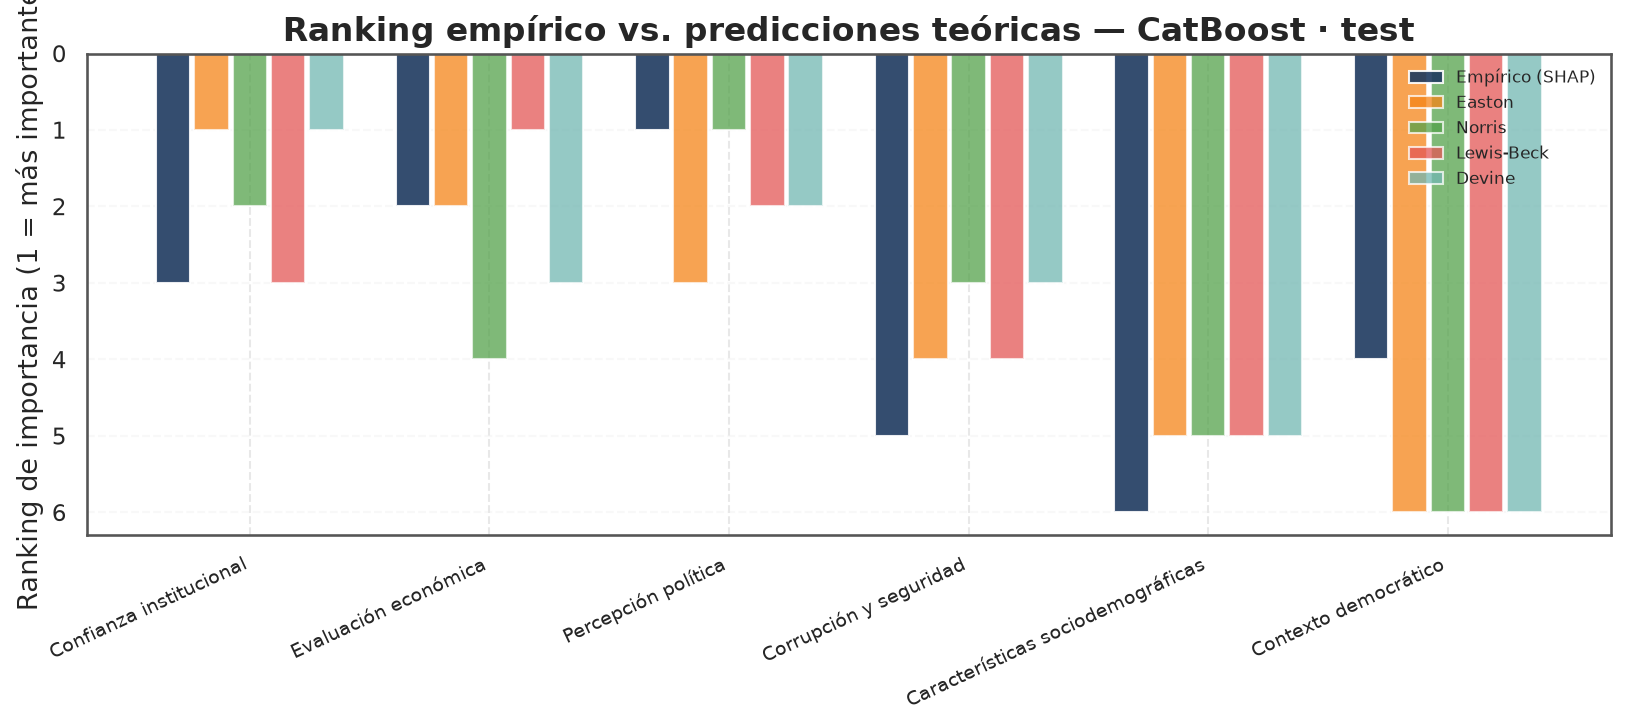

In [9]:
# =============================================================================
# Gráfico de ranking empírico vs. predicciones teóricas
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 5))

teorias_abr = [t.split(" ")[0] for t in teorias]
x = np.arange(len(bloques_lb))
ancho = 0.8 / (len(teorias) + 1)

# Ranking empírico SHAP
rang_emp = [int(imp_bloque_series.rank(ascending=False)[b])
            if b in imp_bloque_series.index else len(bloques_lb)
            for b in bloques_lb]
ax.bar(x, rang_emp, ancho * 0.9,
       label="Empírico (SHAP)", color="#1E3A5F", alpha=0.9)

# Rankings teóricos
colores_t = ["#F58518","#54A24B","#E45756","#72B7B2"]
for j, (teoria, pred) in enumerate(PREDICCIONES_TEORICAS.items()):
    rang_t = [pred.get(b, len(bloques_lb)) for b in bloques_lb]
    ax.bar(x + (j+1)*ancho, rang_t, ancho * 0.9,
           label=teorias_abr[j], color=colores_t[j], alpha=0.75)

ax.invert_yaxis()
ax.set_xticks(x + ancho * len(teorias) / 2)
ax.set_xticklabels(bloques_lb, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Ranking de importancia (1 = más importante)")
ax.set_title(f"Ranking empírico vs. predicciones teóricas — {MODELO_REF} · {SP_REF}",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
save_figure(f"06_ranking_empirico_vs_teorico_{MODELO_REF}")
plt.show()

## 7. Divergencias y nuevas hipótesis

In [10]:
# =============================================================================
# Identificar variables que aparecen en el top-10 SHAP pero que NINGUNA
# teoría predice como importantes → posibles nuevos determinantes
# =============================================================================
print("=" * 65)
print("DIVERGENCIAS — Variables algorítmicamente importantes")
print("pero no predichas como dominantes por ninguna teoría")
print("=" * 65)
print()

top10_vars = importancias.head(10).index.tolist()
for var in top10_vars:
    bloque_v  = bloque_de(var)
    if "V-Dem" in bloque_v:
        continue
    rank_alg  = int(ranking_alg[var])
    predicciones = [pred.get(bloque_v, 5) for pred in PREDICCIONES_TEORICAS.values()]
    rank_min_teo = min(predicciones)

    if rank_min_teo >= 4:
        et = ETIQUETAS_FEATURES.get(var, var)
        print(f"  Ranking {rank_alg}: {et} [{bloque_v}]")
        print(f"    → No predicha como dominante por ninguna teoría")
        print(f"       (rango teórico mínimo: {rank_min_teo}/5)")
        print()

print("Variables teóricamente predichas como dominantes")
print("pero AUSENTES del top-10 SHAP:")
print()
for teoria, pred in PREDICCIONES_TEORICAS.items():
    bloque_dom = min(pred, key=pred.get)
    vars_dom   = [v for v in BLOQUES.get(bloque_dom,[])
                  if v in importancias.index and v not in top10_vars]
    if vars_dom:
        print(f"  {teoria.split('(')[0].strip()} predice '{bloque_dom}' como clave:")
        for v in vars_dom[:3]:
            rank_v = int(ranking_alg[v])
            et     = ETIQUETAS_FEATURES.get(v, v)
            print(f"    Ranking {rank_v}: {et} (no está en top-10)")

DIVERGENCIAS — Variables algorítmicamente importantes
pero no predichas como dominantes por ninguna teoría

  Ranking 7: Componente igualitario [Contexto democrático]
    → No predicha como dominante por ninguna teoría
       (rango teórico mínimo: 5/5)

Variables teóricamente predichas como dominantes
pero AUSENTES del top-10 SHAP:

  Easton predice 'Confianza institucional' como clave:
    Ranking 14: Confianza Poder Judicial (no está en top-10)
    Ranking 18: Confianza Policía (no está en top-10)
    Ranking 19: Confianza Televisión (no está en top-10)
  Norris predice 'Percepción política' como clave:
    Ranking 16: Interés en política (no está en top-10)
  Lewis-Beck & Stegmaier predice 'Evaluación económica' como clave:
    Ranking 13: Expectativa económica país (no está en top-10)
    Ranking 20: Expectativa económica personal (no está en top-10)
  Devine predice 'Confianza institucional' como clave:
    Ranking 14: Confianza Poder Judicial (no está en top-10)
    Ranking 18: 

## 8. Exportación de material para la tesis

In [11]:
# =============================================================================
# Compilar y exportar tablas finales para el capítulo de discusión
# =============================================================================

# Tabla maestra de importancias con bloques y rankings teóricos
tabla_maestra = pd.DataFrame({
    "variable"  : importancias.head(20).index,
    "etiqueta"  : [ETIQUETAS_FEATURES.get(v,v) for v in importancias.head(20).index],
    "bloque"    : [bloque_de(v) for v in importancias.head(20).index],
    "shap_medio": importancias.head(20).values,
    "ranking"   : range(1, 21),
})
for teoria, pred in PREDICCIONES_TEORICAS.items():
    col = teoria.split("(")[0].strip()
    tabla_maestra[f"rank_{col}"] = tabla_maestra["bloque"].map(pred)

tabla_maestra.to_csv(
    PATHS["FOLDER_RESULTS_TABLES"] / f"tabla_maestra_xai_{MODELO_REF}.csv",
    index=False)
print("✓ Tabla maestra XAI guardada")

# Resumen ejecutivo
print()
print("=" * 65)
print("RESUMEN — Contraste teórico")
print("=" * 65)
print(f"  Modelo de referencia: {MODELO_REF} — {SP_REF}")
print(f"  Variables analizadas: {min(20, len(importancias))}")
print()
n_conv = df_tabla_conv["convergencia"].value_counts().to_dict()
print("  Convergencias globales:")
for tipo, n in sorted(n_conv.items()):
    print(f"    {tipo}: {n} variables")
print()
print("Archivos generados:")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("06_*.png")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*convergencia*")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("tabla_maestra*")):
    print(f"  {f.name}")

✓ Tabla maestra XAI guardada

RESUMEN — Contraste teórico
  Modelo de referencia: CatBoost — test
  Variables analizadas: 20

  Convergencias globales:
    Convergencia: 11 variables
    Divergencia: 4 variables
    Parcial: 5 variables

Archivos generados:
  06_convergencias_teoricas_CatBoost.png
  06_ranking_empirico_vs_teorico_CatBoost.png
  06_tabla_convergencias_CatBoost.png
  tabla_convergencias_CatBoost.csv
  tabla_maestra_xai_CatBoost.csv
